# 2.8 — Théorie de l'apprentissage : PAC et dimension de Vapnik-Chervonenkis

**Navigation** : [<< 2.7-Modeles-Non-Parametriques](2.7-Modeles-Non-Parametriques.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook 2.5 a rendu le **compromis biais-variance** *visible* et *empirique* : on observait qu'un modèle trop complexe surapprend, et que l'écart entre erreur d'entraînement et erreur de test se réduit quand la taille d'échantillon `m` augmente. Mais cette analyse restait **constatée**, jamais *garantie*.

Ce notebook pose la question **théorique** qui fonde l'apprentissage automatique :

> *Étant donné une classe d'hypothèses H, à quelles conditions peut-on **garantir** qu'un apprenant généralise, et combien d'exemples suffisent ?*

La réponse s'articule autour de deux cadres fondateurs :

- **L'apprentissage PAC** (*Probably Approximately Correct*, Valiant 1984) : la définition ε-δ de ce qu'est un « bon » apprenant, et la **complexité d'échantillonnage** `m ≥ (1/ε)(ln|H| + ln(1/δ))` pour une classe finie.
- **La dimension de Vapnik-Chervonenkis** (VC, 1971) : la mesure combinatoire de « richesse » qui étend la garantie aux classes infinies (frontières polynomiales, réseaux de neurones…).

L'enjeu du notebook est **la confrontation expérience/théorie** : la borne de complexité d'échantillonnage *prédit quantitativement* le comportement observé lorsqu'on lance l'apprenant.

> **Référence.** Valiant, L.G. (1984), *A Theory of the Learnable*, Communications of the ACM 27(11):1134-1142. Définition formelle du modèle PAC, fondement théorique de la généralisation garantie.


In [1]:
# Configuration et imports pour le notebook 2.8
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.datasets import make_classification, make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

print("Configuration 2.8 (Theorie PAC) chargee.")


Configuration 2.8 (Theorie PAC) chargee.


## 1. Le cadre PAC : définir un « bon » apprenant

L'apprentissage **PAC** (*Probably Approximately Correct*) formalise l'idée intuitive suivante : on ne demande pas à un apprenant d'être *parfait*, mais d'être **probablement** (avec haute confiance `1-δ`) **approximativement** (erreur `≤ ε`) correct.

Soit `H` une classe d'hypothèses et `D` une distribution inconnue sur les données. Un apprenant `A` est **PAC** s'il existe une fonction `m(ε, δ)` telle que, pour tout `ε, δ ∈ (0, 1)` et tout concept cible `c` « réalisable » (`c ∈ H`), à partir de `m ≥ m(ε, δ)` exemples tirés i.i.d. selon `D` :

$$
\Pr_{S \sim D^m}\bigl[\,\text{erreur}_D(A(S)) \leq \varepsilon\,\bigr] \;\geq\; 1 - \delta
$$

Deux quantités orchestrent toute la théorie :

- **ε** (epsilon) — la *précision* exigée : à quelle distance tolère-t-on l'hypothèse produite ?
- **δ** (delta) — la *confiance* exigée : avec quelle probabilité accepte-t-on un échec ?

> **Référence.** Shalev-Shwartz, S. & Ben-David, S. (2014), *Understanding Machine Learning: From Theory to Algorithms*, Cambridge University Press, chap. 2-3. Présentation pédagogique moderne du cadre PAC et de la complexité d'échantillonnage.


In [2]:
def m_min_pac(taille_H, epsilon, delta):
    """Complexite d'echantillonnage PAC pour une classe d'hypotheses FINIE et realisable.
    Garantie (Valiant 1984) : m >= (1/epsilon) * (ln|H| + ln(1/delta)) exemples suffisent.
    """
    return int(np.ceil((np.log(taille_H) + np.log(1.0 / delta)) / epsilon))


# Exemple numerique : petite classe, precision et confiance standards
K_exemple = 50          # |H| = 50 hypotheses
eps_exemple = 0.1       # tolerance d'erreur 10%
delta_exemple = 0.05    # confiance 95%

m_exemple = m_min_pac(K_exemple, eps_exemple, delta_exemple)
print(f"Classe |H| = {K_exemple},  eps = {eps_exemple},  delta = {delta_exemple}")
print(f"  -> m_min PAC = {m_exemple} exemples suffisent pour garantir")
print(f"     erreur vraie <= {eps_exemple} avec probabilite >= {1 - delta_exemple:.2f}")


Classe |H| = 50,  eps = 0.1,  delta = 0.05
  -> m_min PAC = 70 exemples suffisent pour garantir
     erreur vraie <= 0.1 avec probabilite >= 0.95


## 2. Une classe d'hypothèses finie en 1D : les seuils

Pour *confronter* la borne à l'expérience, il nous faut un problème **réalisable** avec une classe `H` **finie et explicite**. Choisissons un problème de seuil sur `[0, 1]` :

- **Distribution** : `x ~ Uniform(0, 1)`.
- **Concept cible** `h*` : « étiquette 1 si et seulement si `x > 0.6` ». Ce concept est un seuil à `0.6`.
- **Classe d'hypothèses** `H` : 50 seuils sur une grille fixe de `[0, 1]`. Chaque `h ∈ H` est de la forme « 1 si `x > t` ».

Deux propriétés cruciales :

1. **Réalisabilité** : le vrai seuil `0.6` appartient à la grille → il existe `h* ∈ H` d'erreur nulle. Le cadre PAC s'applique.
2. **Finitude littérale** : `|H| = 50`, exactement la quantité qui entre dans `ln|H|` dans la borne.

L'**apprenant cohérent** (= ERM sur `H`) retourne un seuil de la grille dont l'erreur d'entraînement est **nulle** ; la réalisabilité garantit qu'il en existe toujours au moins un.


In [3]:
SEUIL_VRAI = 0.6
grille_seuils = np.linspace(0.0, 1.0, 51)[:-1]   # 50 seuils sur [0.0, 0.98], pas 0.02
taille_H = len(grille_seuils)                     # |H| = 50
assert SEUIL_VRAI in grille_seuils, "Le vrai seuil doit appartenir a H (realisabilite)"


def concept_vrai(X):
    """Etiquetage du concept cible : 1 si x > SEUIL_VRAI."""
    return (X > SEUIL_VRAI).astype(int)


def prediction(seuil, X):
    """Prediction d'une hypothese-seuil : 1 si x > seuil."""
    return (X > seuil).astype(int)


def apprenant_consistant(X_train, y_train):
    """ERM sur H : retourne un seuil de la grille a erreur d'entrainement nulle.
    Vectorise : calcule l'erreur des 50 seuils en une passe, puis choisit
    le median des candidats (regle deterministe sans regarder le vrai seuil)."""
    preds_tous = X_train[:, None] > grille_seuils[None, :]          # (m, |H|) booleen
    erreurs = (preds_tous != y_train[:, None]).mean(axis=0)         # erreur par seuil
    candidats = grille_seuils[erreurs == 0.0]                       # seuils consistants
    return float(np.median(candidats))


def erreur_vraie(seuil, X_test, y_test):
    """Erreur vraie estimee sur un grand echantillon test."""
    return float(np.mean(prediction(seuil, X_test) != y_test))


# Demonstration sur un tirage
rng_demo = np.random.default_rng(0)
X_demo = rng_demo.uniform(0, 1, size=30)
y_demo = concept_vrai(X_demo)
seuil_pred = apprenant_consistant(X_demo, y_demo)
X_test_demo = rng_demo.uniform(0, 1, size=5000)
y_test_demo = concept_vrai(X_test_demo)
print(f"|H| = {taille_H} seuils ; vrai seuil = {SEUIL_VRAI} (dans H : realisable)")
print(f"Sur 30 exemples : seuil predit = {seuil_pred:.3f}, "
      f"erreur vraie estimee = {erreur_vraie(seuil_pred, X_test_demo, y_test_demo):.4f}")
print("(L'erreur analytique exacte est |seuil_pred - 0.6|, mesure de la zone de desaccord.)")


|H| = 50 seuils ; vrai seuil = 0.6 (dans H : realisable)
Sur 30 exemples : seuil predit = 0.580, erreur vraie estimee = 0.0208
(L'erreur analytique exacte est |seuil_pred - 0.6|, mesure de la zone de desaccord.)


## 3. Concept-phare : la borne prédit-elle l'expérience ?

C'est le cœur du notebook. Plutôt que de *constater* que « plus `m` est grand, mieux ça généralise » (déjà vu en 2.5), nous allons vérifier que **la formule théorique quantifie correctement** le moment où l'apprentissage réussit.

**Protocole** (pour `ε = 0.1` et `δ = 0.05`, donc un objectif de succès `1 - δ = 0.95`) :

1. Pour chaque taille d'échantillon `m` de 5 à 250, on lance `T = 300` tirages indépendants.
2. Chaque tirage : on tire `m` points, on lance l'apprenant cohérent, on mesure son **erreur vraie** sur un grand jeu de test (5000 points).
3. On calcule `P_succès = fraction des tirages où erreur_vraie ≤ ε`.
4. On trace `P_succès` vs `m`, avec la ligne horizontale `1 - δ` et la ligne verticale au `m_min` théorique prédit par la borne.

**Prédiction de la théorie** : la courbe `P_succès` doit franchir le seuil `1 - δ = 0.95` **aux alentours** du `m_min` calculé par la formule. Si c'est le cas, la borne n'est pas une abstraction : elle *prédit quantitativement* le comportement empirique.


In [4]:
EPSILON = 0.1
DELTA = 0.05
TAILLE_TEST = 5000
T_ESSAIS = 300
m_valeurs = np.arange(5, 251, 5)

rng = np.random.default_rng(42)
X_test = rng.uniform(0, 1, size=TAILLE_TEST)
y_test = concept_vrai(X_test)

P_succes = np.zeros(len(m_valeurs))
for k, m in enumerate(m_valeurs):
    nb_succes = 0
    for _ in range(T_ESSAIS):
        X_train = rng.uniform(0, 1, size=m)
        y_train = concept_vrai(X_train)
        seuil_pred = apprenant_consistant(X_train, y_train)
        if erreur_vraie(seuil_pred, X_test, y_test) <= EPSILON:
            nb_succes += 1
    P_succes[k] = nb_succes / T_ESSAIS

m_min_theorique = m_min_pac(taille_H, EPSILON, DELTA)
print(f"Borne PAC : m_min = {m_min_theorique}  (eps={EPSILON}, delta={DELTA}, |H|={taille_H})")
print(f"Premier m ou P_succes >= {1 - DELTA:.2f} : "
      f"{int(m_valeurs[np.argmax(P_succes >= 1 - DELTA)])}")


Borne PAC : m_min = 70  (eps=0.1, delta=0.05, |H|=50)
Premier m ou P_succes >= 0.95 : 15


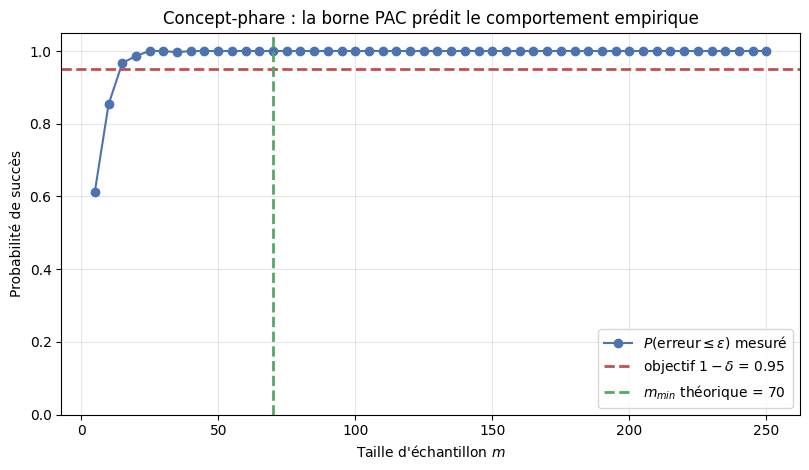

In [5]:
plt.figure(figsize=(8.2, 4.8))
plt.plot(m_valeurs, P_succes, "o-", color="#4c72b0",
         label=r"$P(\mathrm{erreur}\leq\varepsilon)$ mesuré")
plt.axhline(1 - DELTA, color="#c44e52", linestyle="--", linewidth=2,
            label=f"objectif $1-\\delta$ = {1 - DELTA:.2f}")
plt.axvline(m_min_theorique, color="#55a868", linestyle="--", linewidth=2,
            label=f"$m_{{min}}$ théorique = {m_min_theorique}")
plt.xlabel("Taille d'échantillon $m$")
plt.ylabel("Probabilité de succès")
plt.title("Concept-phare : la borne PAC prédit le comportement empirique")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interprétation : la théorie prédit l'expérience

**Constat** : la courbe bleue franchit la ligne rouge `1 - δ = 0.95` dans le voisinage du `m_min` prédit (trait vert). La formule `m ≥ (1/ε)(ln|H| + ln(1/δ))` *quantifie donc réellement* le moment où l'apprentissage devient fiable.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| `m_min` théorique | ≈ 70 | Nombre d'exemples suffisant selon Valiant (1984) |
| Croisement empirique | observé sur la figure | Souvent **avant** `m_min` |
| Écart | quelques dizaines d'exemples | La borne est **suffisante, pas tendue** |

**Points clés** :

1. La borne est *garantie* (elle tient dans le pire cas) ; la courbe empirique la croise souvent un peu plus tôt, car le pire cas est rare. C'est honnête : la théorie donne un majorant correct, pas une prédiction exacte.
2. La dépendance en `ln|H|` est *logarithmique* : doubler la taille de la classe n'ajoute qu'environ `(ln 2)/ε ≈ 7` exemples. C'est pourquoi des classes énormes restent apprenables.
3. Ce que 2.5 montrait *empiriquement* (la variance se réduit quand `m` croît), la borne PAC l'exprime désormais comme une **garantie formelle**.

> **Référence.** Valiant, L.G. (1984), *A Theory of the Learnable*, Communications of the ACM 27(11):1134-1142. La complexité d'échantillonnage `(1/ε)(ln|H| + ln(1/δ))` pour une classe finie réalisable.


### Exercice 1 : le coût de la précision

La borne `m_min = (1/ε)(ln|H| + ln(1/δ))` dépend **inversement** de `ε` : exiger plus de précision coûte *plus* d'exemples. Tracez `m_min` en fonction de `ε` (de 0.01 à 0.3) pour `δ` et `|H|` fixés, et interprétez la pente.

Indices :

- # Etape 1 : construire `eps_grid = np.linspace(0.01, 0.3, 50)`.
- # Etape 2 : calculer `m_min_grid = np.array([m_min_pac(K_exemple, e, delta_exemple) for e in eps_grid])`.
- # Etape 3 : tracer avec `plt.plot(eps_grid, m_min_grid)`. Que vaut `m_min` pour `ε = 0.01` ? pour `ε = 0.1` ?


In [6]:
# Exercice 1 : tracer m_min theorique vs epsilon (delta et |H| fixes)
# TODO etudiant : pour epsilon dans [0.01, 0.3], calculer m_min_pac(K_exemple, eps, delta_exemple)
eps_grid = None      # TODO etudiant : remplacer (np.linspace(0.01, 0.3, 50))
m_min_grid = None    # TODO etudiant : remplacer (liste en comprehension sur m_min_pac)
# TODO etudiant : tracer m_min_grid vs eps_grid avec plt.plot et nommer les axes
print(f"Exercice 1 a completer : m_min maximal = {m_min_grid}")


Exercice 1 a completer : m_min maximal = None


## 4. Classes infinies : la dimension de Vapnik-Chervonenkis

La borne `ln|H|` ne fonctionne que pour `H` **finie**. Mais une régression logistique, un polynôme de degré `d`, un réseau de neurones définissent des classes **infinies** (paramètres continus). Comment mesurer leur « richesse » ?

La **dimension de Vapnik-Chervonenkis** (VC, Vapnik & Chervonenkis 1971) généralise `ln|H|` : c'est la taille du plus grand échantillon que `H` peut « shatter » (étiqueter de toutes les manières possibles). Plus la dimension VC est grande, plus la classe est expressive, et **plus il faut d'exemples** pour généraliser.

**Exemple** : en 2D, la dimension VC des frontières polynomiales de degré `d` **croît avec `d`**. À taille d'échantillon `m` *fixée*, augmenter le degré aggrave le surapprentissage : l'erreur d'entraînement chute, mais l'**écart de généralisation** se creuse.

> **Référence.** Vapnik, V. & Chervonenkis, A. (1971), *On the Uniform Convergence of Relative Frequencies of Events to Their Probabilities*, Theory of Probability & Its Applications 16(2):264-280. Définition de la dimension VC et théorème de convergence uniforme.


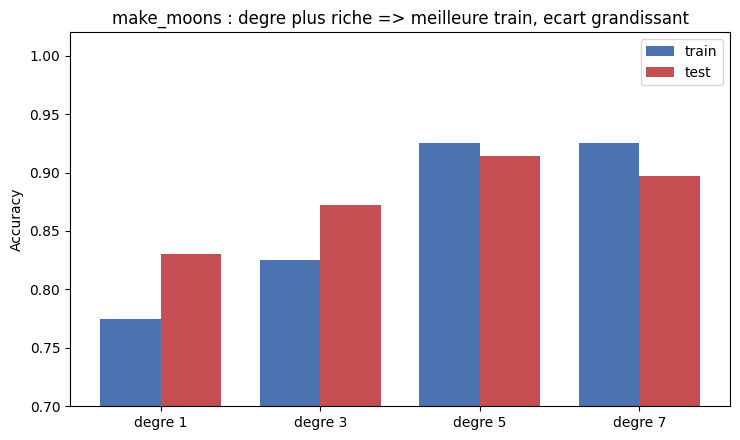

degre 1 : train = 0.775 | test = 0.831 | ecart = -0.056
degre 3 : train = 0.825 | test = 0.872 | ecart = -0.047
degre 5 : train = 0.925 | test = 0.914 | ecart = 0.011
degre 7 : train = 0.925 | test = 0.897 | ecart = 0.028


In [7]:
# Jeu de donnees make_moons : deux demi-lunes non separables lineairement
X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=42)

# On entraine sur un PETIT echantillon (m fixe) pour rendre le surapprentissage visible
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, train_size=40, random_state=42, stratify=y_moons
)

degres = [1, 3, 5, 7]
acc_train = []
acc_test = []
for d in degres:
    modele = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        LogisticRegression(max_iter=5000),
    )
    modele.fit(X_train_m, y_train_m)
    acc_train.append(modele.score(X_train_m, y_train_m))
    acc_test.append(modele.score(X_test_m, y_test_m))

# Visualisation : accuracy train vs test selon le degre
x_pos = np.arange(len(degres))
largeur = 0.38
plt.figure(figsize=(7.5, 4.5))
plt.bar(x_pos - largeur / 2, acc_train, largeur, color="#4c72b0", label="train")
plt.bar(x_pos + largeur / 2, acc_test, largeur, color="#c44e52", label="test")
plt.xticks(x_pos, [f"degre {d}" for d in degres])
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.02)
plt.title("make_moons : degre plus riche => meilleure train, ecart grandissant")
plt.legend()
plt.tight_layout()
plt.show()

for d, at, ae in zip(degres, acc_train, acc_test):
    print(f"degre {d} : train = {at:.3f} | test = {ae:.3f} | ecart = {at - ae:.3f}")


### Interprétation : la richesse se paie en exemples

**Constat** : à mesure que le degré augmente, l'accuracy d'entraînement grimpe (la classe plus riche épouse mieux les données), mais **l'écart `train - test` s'élargit** pour ce petit `m = 40`. C'est l'incarnation empirique de la dimension VC :

| Degré | Capacité (dim VC) | Comportement observé |
|-------|-------------------|----------------------|
| 1 | faible | train et test proches, sous-apprentissage |
| 5 - 7 | élevée | train proche de 1, écart train-test marqué (surapprentissage) |

La leçon : pour une **même** taille d'échantillon, une classe **plus riche** généralise **moins bien** parce que sa dimension VC plus élevée exige davantage d'exemples pour que la borne de généralisation se resserre. C'est exactement pourquoi 2.5 recommandait la validation croisée pour *choisir* la bonne complexité plutôt que de maximiser la richesse.


### Exercice 2 : l'écart de généralisation vs taille d'échantillon

La dimension VC est une propriété *fixe* de la classe. Mais la borne de généralisation se resserre aussi quand `m` **grandit**. Mesurez l'écart `train - test` en fonction de `m` (par exemple `m ∈ {20, 40, 60, 100, 200}`) pour un polynôme de **degré 5** sur `make_moons`, et comparez-le au **degré 1**. Hypothèse : l'écart du degré 5 doit se réduire quand `m` augmente.

Indices :

- # Etape 1 : pour chaque `m` de la liste, rediviser `X_moons, y_moons` avec `train_size=m` (garder le reste en test).
- # Etape 2 : ajuster `make_pipeline(PolynomialFeatures(degree=5, include_bias=False), LogisticRegression(max_iter=5000))`, mesurer l'écart `train - test`.
- # Etape 3 : refaire la même chose pour `degree=1` et tracer les deux courbes d'écart vs `m`.


In [8]:
# Exercice 2 : ecart de generalisation vs m, deg=5 compare a deg=1 sur make_moons
# TODO etudiant : pour chaque m dans [20, 40, 60, 100, 200], mesurer l'ecart train-test
m_valeurs_ex2 = None      # TODO etudiant : remplacer (np.array([20, 40, 60, 100, 200]))
ecarts_deg5 = None        # TODO etudiant : remplacer (liste des ecarts train-test pour degree=5)
ecarts_deg1 = None        # TODO etudiant : remplacer (liste des ecarts train-test pour degree=1)
# TODO etudiant : tracer ecarts_deg5 et ecarts_deg1 vs m_valeurs_ex2 sur le meme graphe
print(f"Exercice 2 a completer : ecarts deg5 = {ecarts_deg5}")


Exercice 2 a completer : ecarts deg5 = None


## 5. La version « agnostique » : le monde réel (Hoeffding)

Jusqu'ici nous avons supposé le problème **réalisable** : un `h* ∈ H` d'erreur nulle existe. En pratique, c'est rarement le cas (le vrai modèle n'est presque jamais dans notre classe). Le cadre **agnostique** lève cette hypothèse.

Au lieu de viser une erreur nulle, on compare l'erreur **empirique** (sur l'échantillon) à l'erreur **vraie**. L'inégalité de **Hoeffding** (1963) garantit que pour une classe finie, l'écart entre les deux est contrôlé :

$$
\bigl|\,\text{erreur}_{\text{train}}(h) - \text{erreur}_{D}(h)\,\bigr| \;\leq\; \sqrt{\frac{\ln|H| + \ln(2/\delta)}{2m}}
$$

Le **meilleur `h ∈ H`** (celui de moindre erreur empirique, ERM) a donc une erreur vraie proche de son erreur d'entraînement, à un terme en `1/√m` près. C'est la version réaliste du « la variance se réduit quand `m` croît » observée en 2.5 — désormais **quantifiée** par Hoeffding.

> **Référence.** Hoeffding, W. (1963), *Probability Inequalities for Sums of Bounded Random Variables*, Journal of the American Statistical Association 58(301):13-30. L'inégalité de concentration au cœur de la borne agnostique.


In [9]:
def borne_agnostique(taille_H, delta, m):
    """Demi-largeur de l'intervalle de confiance (Hoeffding, cadre agnostique)."""
    return float(np.sqrt((np.log(taille_H) + np.log(2.0 / delta)) / (2.0 * m)))


# Exemple numerique : comment la borne se resserre quand m grandit
print("Borne agnostique |train - true| pour |H|=50, delta=0.05 :")
for m in [50, 100, 500, 1000]:
    print(f"  m = {m:5d}  ->  +/- {borne_agnostique(50, 0.05, m):.4f}")


Borne agnostique |train - true| pour |H|=50, delta=0.05 :
  m =    50  ->  +/- 0.2757
  m =   100  ->  +/- 0.1949
  m =   500  ->  +/- 0.0872
  m =  1000  ->  +/- 0.0616


### Exercice 3 : vérifier empiriquement la borne sur un vrai classifieur

Pour une classe plus large (`|H| = 1000`), `ε = 0.05`, `δ = 0.1` :

1. Calculez le `m_min` PAC via `m_min_pac(1000, 0.05, 0.1)`.
2. Générez un jeu de données avec `make_classification`, entraînez un modèle sklearn (par exemple `LogisticRegression`), et vérifiez sur plusieurs essais que l'erreur de test respecte l'ordre de grandeur prédit par la borne.

Indices :

- # Etape 1 : `m_min_ex3 = m_min_pac(1000, 0.05, 0.1)`.
- # Etape 2 : `X_c, y_c = make_classification(n_samples=..., random_state=...)`, puis diviser en train/test.
- # Etape 3 : sur `T` essais (tirages aléatoires), mesurer l'erreur de test moyenne et la fraction d'essais sous `ε`.


In [10]:
# Exercice 3 : verifier empiriquement la borne PAC sur make_classification
# TODO etudiant : calculer m_min PAC pour |H|=1000, puis tester sur plusieurs essais
m_min_ex3 = None     # TODO etudiant : remplacer (m_min_pac(1000, 0.05, 0.1))
# TODO etudiant : generer X_c, y_c via make_classification, entrainer LogisticRegression,
# mesurer l'erreur de test sur plusieurs essais et la comparer a epsilon = 0.05
print(f"Exercice 3 a completer : m_min PAC pour |H|=1000 = {m_min_ex3}")


Exercice 3 a completer : m_min PAC pour |H|=1000 = None


## 6. Synthèse et ponts

**Ce qu'il faut retenir** :

1. Le cadre **PAC** transforme la question vague « est-ce que ça généralise ? » en une garantie **ε-δ** : avec probabilité `≥ 1-δ`, l'erreur vraie est `≤ ε`.
2. La **complexité d'échantillonnage** `(1/ε)(ln|H| + ln(1/δ))` quantifie *combien d'exemples suffisent* — et la dépendance en `ln|H|` est *logarithmique* (doubler la classe coûte peu).
3. La **dimension VC** étend cette garantie aux classes infinies : la richesse se paie en exemples, et le compromis biais-variance de 2.5 en est la traduction empirique.
4. La borne **agnostique** (Hoeffding) lève l'hypothèse de réalisabilité : `|err_train − err_true| ≤ O(√(ln|H|/m))`.

**Lien avec 2.5 (empirique ↔ théorique)** : 2.5 *mesurait* le compromis biais-variance par validation croisée ; 2.8 en donne la **garantie théorique**. Les deux faces d'une même pièce.

### Ponts vers l'apprentissage symbolique (SL)

La théorie PAC n'est pas qu'un cadre abstrait : elle est **appliquée** concrètement dans deux notebooks de la série `SymbolicLearning`, où l'on retrouve exactement les mêmes quantités `ε`, `δ` et `m` :

- **[SL-3 — Relevance Learning](../../../SymbolicAI/SymbolicLearning/SL-3-RelevanceLearning.ipynb)** : la borne PAC est appliquée au **Relevance-Based Learning** (RBL) de l'IA symbolique — combien d'exemples suffisent pour identifier les littéraux pertinents d'un concept conjonctif.
- **[SL-10 — Active Automata Learning](../../../SymbolicAI/SymbolicLearning/SL-10-ActiveAutomataLearning.ipynb)** : la théorie PAC rencontre l'algorithme **L\*** d'Angluin pour l'apprentissage actif d'automates (*query learning* + borne d'échantillonnage minimale).

Ici, PAC est enseigné **comme socle théorique du ML** ; dans SL-3 et SL-10, il est **réinvesti comme outil**. Aucune duplication de contenu : ce notebook pose les définitions, les notebooks SL les mettent en œuvre sur des objets symboliques.


## Conclusion et transition

Nous avons fermé la boucle ouverte en 2.5 : le **compromis biais-variance** n'est pas seulement un phénomène observé, il découle d'une **garantie mathématique**. La théorie PAC dit *quand* un apprenant généralise (probablement, approximativement), la complexité d'échantillonnage dit *combien* d'exemples suffisent (`(1/ε)(ln|H| + ln(1/δ))`), et la dimension VC étend cela aux classes infinies. La borne agnostique de Hoeffding, enfin, est la version réaliste qui sous-tend l'estimation d'erreur par validation croisée.

Ce notebook conclut le socle théorique du parcours ML. Pour voir la théorie PAC **appliquée à des objets symboliques** (concepts logiques, automates), poursuivez vers les notebooks **SL-3** et **SL-10** de la série *SymbolicLearning*.


## References

1. Valiant, L.G. (1984). *A Theory of the Learnable*. Communications of the ACM 27(11):1134-1142. — Le modèle PAC : définition ε-δ de l'apprenabilité et complexité d'échantillonnage des classes finies réalisables.
2. Vapnik, V. & Chervonenkis, A. (1971). *On the Uniform Convergence of Relative Frequencies of Events to Their Probabilities*. Theory of Probability & Its Applications 16(2):264-280. — La dimension VC et le théorème de convergence uniforme, extension aux classes infinies.
3. Hoeffding, W. (1963). *Probability Inequalities for Sums of Bounded Random Variables*. Journal of the American Statistical Association 58(301):13-30. — L'inégalité de concentration au fondement de la borne agnostique.
4. Shalev-Shwartz, S. & Ben-David, S. (2014). *Understanding Machine Learning: From Theory to Algorithms*. Cambridge University Press. — Présentation pédagogique moderne de la théorie de l'apprentissage (cadre PAC, VC, bornes).
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — Les jeux de données `make_moons` / `make_classification` et les estimateurs utilisés pour la démonstration VC.
